## Section - 1 : Importing and Loading Data

In [3]:
# We bring in all the tools we need before doing anything else

import pandas as pd                   # To load and work with the CSV like a spreadsheet
import numpy as np                    # for math operations
import matplotlib.pyplot as plt       # draws charts and graphs
import seaborn as sns                 # makes charts look nicer with less code

# scikit-learn (sklearn) is Python's main machine learning library
from sklearn.model_selection import train_test_split      # splits data into train and test
from sklearn.preprocessing import LabelEncoder            # converts text columns to numbers
from sklearn.tree import DecisionTreeClassifier           # Model 1: Decision Tree
from sklearn.ensemble import RandomForestClassifier       # Model 2: Random Forest
from sklearn.linear_model import LogisticRegression       # Model 3: Logistic Regression
from sklearn.metrics import (
    accuracy_score,           # % of correct predictions
    classification_report,    # detailed breakdown: precision, recall, F1
    confusion_matrix,         # table: what did the model get right vs wrong
    ConfusionMatrixDisplay )   # turns confusion matrix into a chart

Total rows and columns: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 3 rows of data:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
# Load the CSV file into a DataFrame (df)

df = pd.read_csv('student_data.csv')

In [8]:
# Loading and displaying the Data and with its columns.

print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows of data:")
df.head(5)


Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows of data:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


##  Section - 2 : Exploratory Data Analysis (EDA)

In [10]:
# Before building any mode trying to look and understand the data we have.

# Basic Data Overview

print("Dataset size:", df.shape)                        # Checking no. of rows and columns
print("Missing values:", df.isnull().sum().sum())       # checking if any missing values
print("\nBasic stats for numeric columns:")
print(df.describe())                                    # shows min, max, average, etc. for all possible columns

Dataset size: (395, 33)
Missing values: 0

Basic stats for numeric columns:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443   

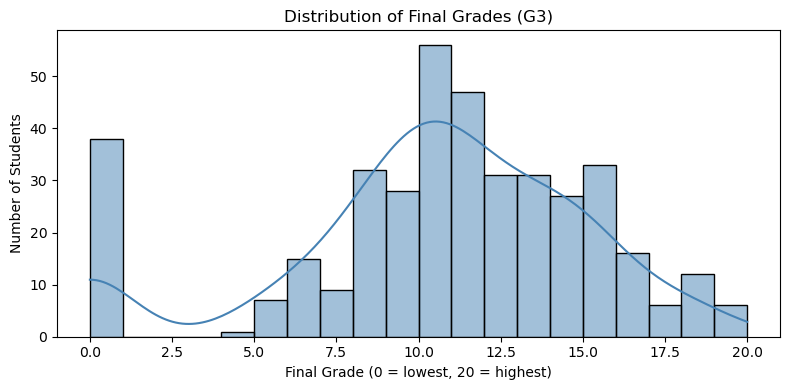

In [18]:
# Final Grade Distribution 

# This chart shows how many students got each grade (0 to 20)
# It helps us understand if grades spread evenly? skewed?

plt.figure(figsize=(8, 4))                                    # to set chart size
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')  # bar chart + smooth curve
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (0 = lowest, 20 = highest)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('Grade_Distribution.png')                         # saving the image for our report
plt.show()

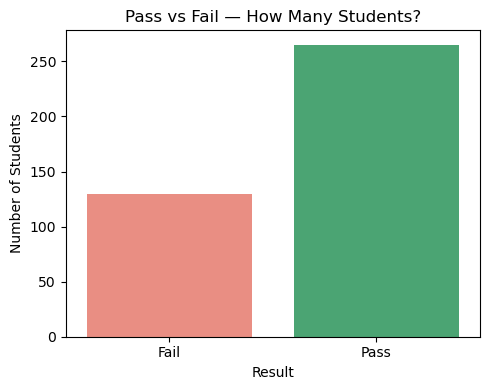

pass_label
Pass    265
Fail    130
Name: count, dtype: int64


In [20]:
# Pass vs Fail Count

# A student PASSES if their G3 grade is 10 or above. Can be changed based on the pass/fail criteria we want.
# This chart shows how many students passed vs failed overall

df['pass_label'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')

plt.figure(figsize=(5, 4))
sns.countplot(x='pass_label', data=df, palette=['salmon', 'mediumseagreen'], hue='pass_label',
              order=['Fail', 'Pass'], legend=False)
plt.title('Pass vs Fail — How Many Students?')
plt.xlabel('Result')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('pass_fail_count.png')
plt.show()

# Print the exact numbers
print(df['pass_label'].value_counts())


In [21]:
# Result: Pass = 265 (67.1%) Studentsn & Fail = 130 (32.9%)

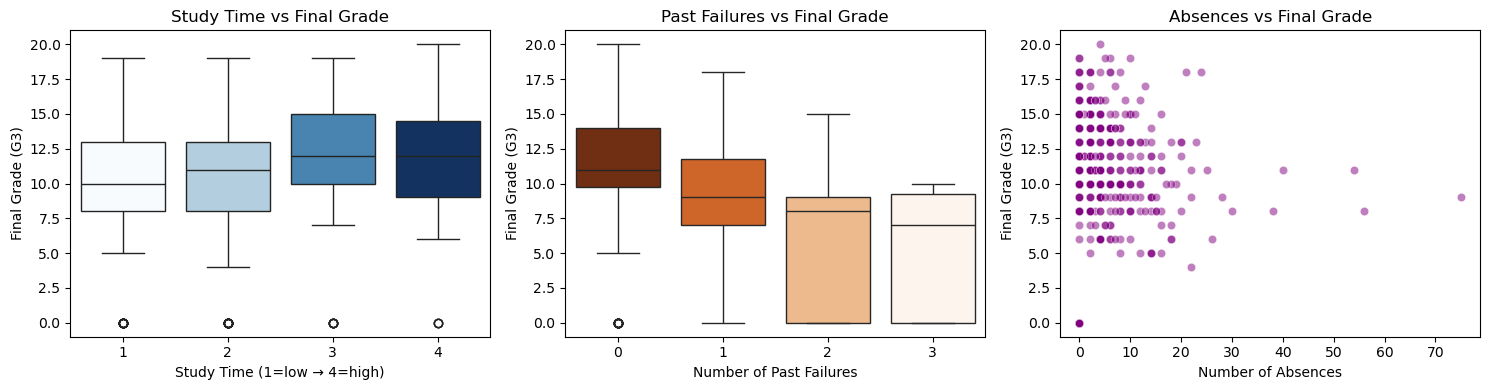

In [23]:
# Three Key Factors vs Final Grade

# These 3 side-by-side charts show how study time, past failures, and absences relate to the final grade
# This is our visual proof that these factors matter

fig, axes = plt.subplots(1, 3, figsize=(15, 4))        # 3 charts in one row

# Chart 1: Study time vs Grade

# studytime: 1 =< 2hrs/week, 2 = 2-5hrs, 3 = 5-10hrs, 4 => 10hrs

sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0], palette='Blues', hue='studytime', legend=False)
axes[0].set_title('Study Time vs Final Grade')
axes[0].set_xlabel('Study Time (1=low → 4=high)')
axes[0].set_ylabel('Final Grade (G3)')

# Chart 2: Past failures vs Grade

# failures: number of past class failures (0, 1, 2, 3)

sns.boxplot(x='failures', y='G3', data=df, ax=axes[1], palette='Oranges_r', hue='failures', legend=False)
axes[1].set_title('Past Failures vs Final Grade')
axes[1].set_xlabel('Number of Past Failures')
axes[1].set_ylabel('Final Grade (G3)')

# Chart 3: Absences vs Grade

# absences: total school absences during the year

sns.scatterplot(x='absences', y='G3', data=df, ax=axes[2], alpha=0.5, color='purple')
axes[2].set_title('Absences vs Final Grade')
axes[2].set_xlabel('Number of Absences')
axes[2].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.savefig('key_factors.png')
plt.show()

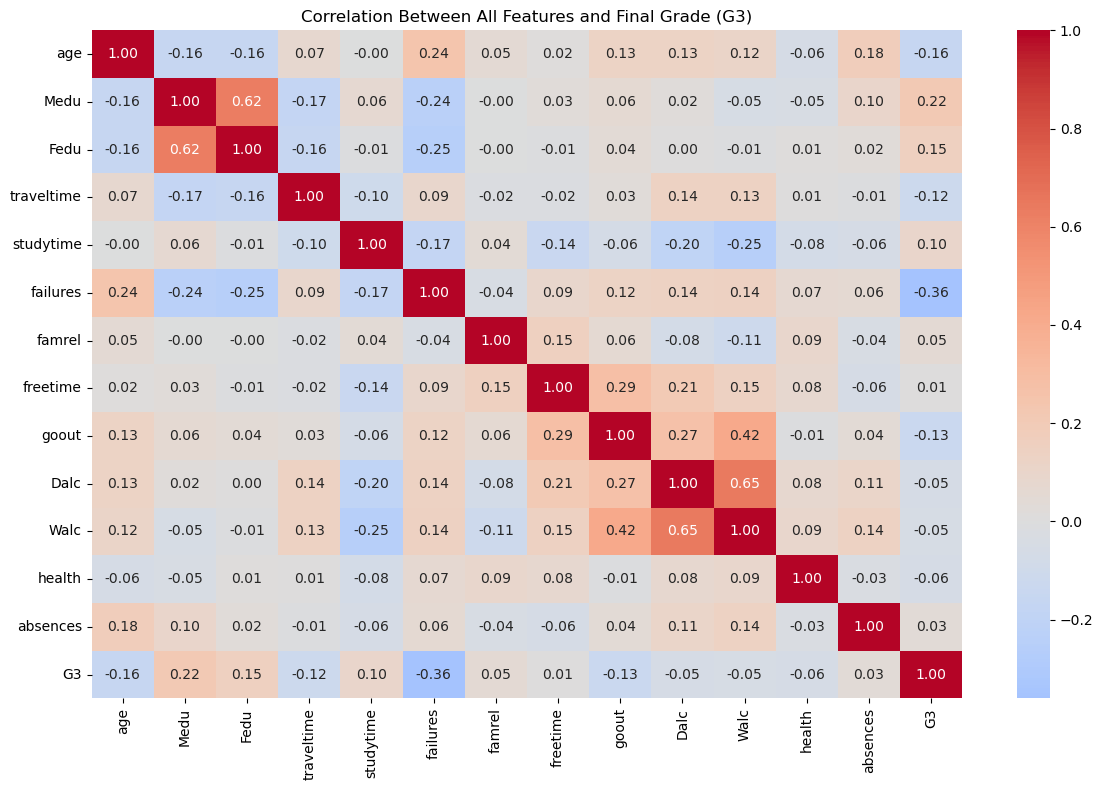

In [24]:
# Correlation Heatmap

# Shows which numeric features are most relataed to G3
# Values close to +1 = strong positive link
# Values close to -1 = strong negative link
# We EXCLUDE G1 and G2 here i.e. prior grades. (Will explain why in preprocessing stage)

numeric_cols = df.select_dtypes(include='number').drop(columns=['G1', 'G2'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between All Features and Final Grade (G3)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Section - 3 : Data PreProcessing

In [26]:
# Prepare the data in the format ML models need
# ML models only understand numbers and no text allowed

# Making a clean copy of our Dataframe
# We don't modify the original df and work on a copy because else we will need to always reload the whole file again from top

df_model = df.drop(columns=['pass_label']).copy()      # Removed the pass/fail the column I added in EDA section above.

print("Starting shape:", df_model.shape)

Starting shape: (395, 33)


In [29]:
# Creating the Target Variable (what we want to predict) i.e.
# G3 >= 10 → 1 (Pass)
# G3 <  10 → 0 (Fail)
# This is called BINARIZATION — turning a range into two categories.

df_model['pass'] = (df_model['G3'] >= 10).astype(int)

print("Pass/Fail counts:")
print(df_model['pass'].value_counts())

# 1 (Pass): 265 students
# 0 (Fail): 130 students

print(f"\nPass rate: {df_model['pass'].mean():.1%}")

Pass/Fail counts:
pass
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%


In [35]:
# Converting Text Columns to Numbers
# Examples of text that need converting:
#   'yes' → 1,  'no' → 0
#   'F'   → 0,  'M'  → 1 (Sex Column)
#   'GP'  → 0,  'MS' → 1 (Student's School Column)
# LabelEncoder does this automatically for every text column

le = LabelEncoder()

# Finding all columns that still contain text (strings)

text_columns = df_model.select_dtypes(include='object').columns

print("Text columns being converted:", text_columns.tolist())


Text columns being converted: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [39]:
# Loop through each text column and convert it to numbers

for col in text_columns:
    df_model[col] = le.fit_transform(df_model[col])

print("\nAll text columns converted to numbers.")
print("Sample of converted data:")
df_model.head(5)


All text columns converted to numbers.
Sample of converted data:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


In [41]:
print("Current shape:", df_model.shape) # A column increased because we added the pass column which is our target variable

Current shape: (395, 34)


In [42]:
# Separating Features (X) from Target (y)

# X = the input data the model will use to make predictions i.e = all the life/social/family factors (30 columns)
# y = the output we want to predict = Pass or Fail (1 column)

# We Drop these 3 columns from X:
# G3 → this is our target and so we cannot use it to predict itself
# G1, G2 → these are earlier grades, too directly linked to G3 so keeping them would let the model kind of cheat or learn wrong
# In real life, a school uses this before seeing final grades

X = df_model.drop(columns=['G1', 'G2', 'G3', 'pass'])
y = df_model['pass']

print("X shape (features):", X.shape)    # (395, 30)
print("y shape (target):", y.shape)      # (395,)
print("\nFeatures being used:", X.columns.tolist())

X shape (features): (395, 30)
y shape (target): (395,)

Features being used: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [44]:
# Splitting the data into Training and Testing Sets
# Training set (80%) i.e. the model learns from this
# Testing set  (20%) i.e. we check accuracy on data the model has never seen

# random_state=42 : This makes the split the same every time we run it

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to testing
    random_state=42       # "seed" — ensures same split every run
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")    
print(f"Total:            {X_train.shape[0] + X_test.shape[0]}") 

Training samples: 316
Testing samples:  79
Total:            395


## Section - 4 : 3 Machine Learning Models

In [46]:
# We train each model on X_train/y_train
# Then test it on X_test/y_test (data it has NEVER seen)

# Model 1: Decision Tree

# Imagine a flowchart of yes/no questions:
# "Did the student have past failures? YES → Did they study > 2hrs? NO → Predict: FAIL"
# The model finds the best questions automatically from the data

dt_model = DecisionTreeClassifier(
    max_depth=5,      # max 5 levels deep — prevents overfitting (memorizing instead of learning)
    random_state=42   # same result every run
)

dt_model.fit(X_train, y_train)            # TRAIN: model reads training data and learns patterns
dt_predictions = dt_model.predict(X_test) # TEST: make predictions on the 79 unseen students

dt_acc = accuracy_score(y_test, dt_predictions)
print(f" Decision Tree Accuracy: {dt_acc:.2%}")

 Decision Tree Accuracy: 73.42%


In [47]:
# Model 2 : Random Forest

# Instead of one tree, it builds 100 different Decision Trees
# Each tree sees a random portion of the data
# Final answer = majority vote across all 100 trees
# Like asking 100 teachers to grade a student can be more fair than just 1

rf_model = RandomForestClassifier(
    n_estimators=100,  # build 100 trees
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_predictions)
print(f" Random Forest Accuracy: {rf_acc:.2%}")   

 Random Forest Accuracy: 72.15%


In [48]:
# Model 3 : Logistic Regression

# Despite the name, this is a classification model
# It calculates a PROBABILITY (0% to 100%) that a student will pass
# If probability > 50% → Predict Pass
# If probability ≤ 50% → Predict Fail
# It's the simplest model because it uses a single mathematical formula

lr_model = LogisticRegression(
    max_iter=1000,   # This number means how many times the formula adjusts itself during training
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_predictions)
print(f" Logistic Regression Accuracy: {lr_acc:.2%}")

 Logistic Regression Accuracy: 75.95%


In [49]:
# Summary : Comparing all 3 models side by side

summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [f'{dt_acc:.2%}', f'{rf_acc:.2%}', f'{lr_acc:.2%}']
})
print("\n=== MODEL ACCURACY COMPARISON ===")
print(summary.to_string(index=False))
print("\n Best model: Logistic Regression (75.95%)")


=== MODEL ACCURACY COMPARISON ===
              Model Accuracy
      Decision Tree   73.42%
      Random Forest   72.15%
Logistic Regression   75.95%

 Best model: Logistic Regression (75.95%)


## Section - 5 : Results and Visualisations

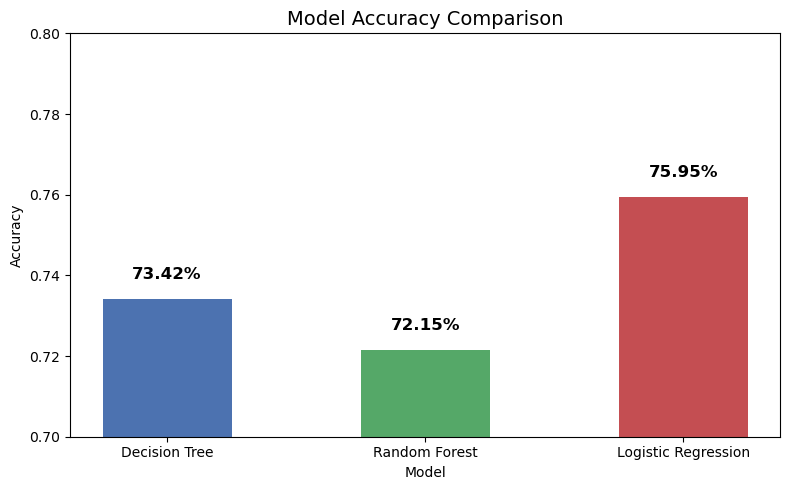

In [59]:
# Now we visualize how all 3 models performed

# Accuracy Comparison Bar Chart
# Simple bar chart — one bar per model, height = accuracy

model_names = ['Decision Tree', 'Random Forest', 'Logistic Regression']
accuracies   = [dt_acc, rf_acc, lr_acc]
colors       = ['#4C72B0', '#55A868', '#C44E52']   # blue, green, red

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, width=0.5)

# Adding the % number on top of each bar so it's easy to read
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar
        bar.get_height() + 0.005,           # just above the bar
        f'{acc:.2%}',                       # e.g. "75.95%"
        ha='center', fontsize=12, fontweight='bold'
    )

plt.ylim(0.70, 0.80)         # y-axis from 70% to 90% (so bars look different, not squished)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.tight_layout()
plt.savefig('accuracy_comparison.png')
plt.show()

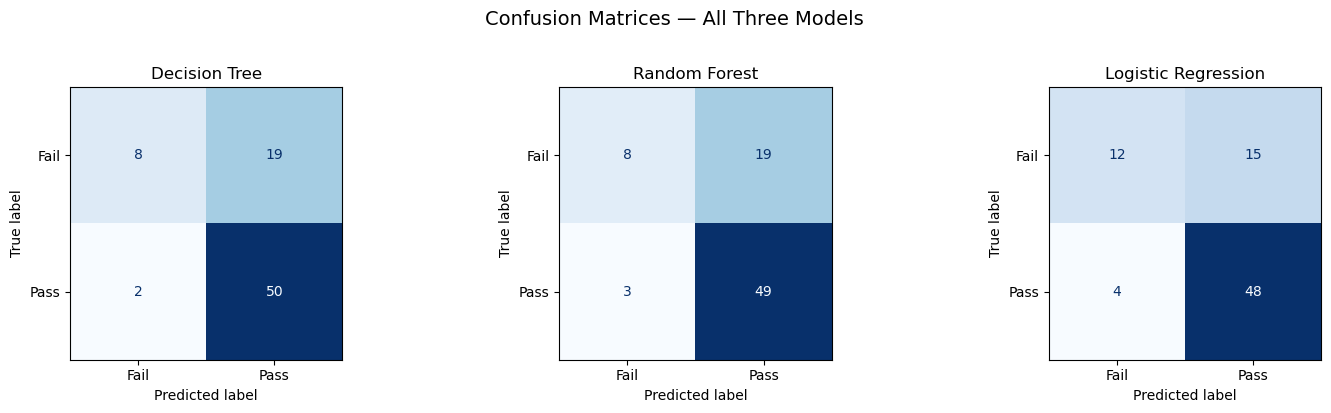

In [60]:
# Confusion Matrices
# A confusion matrix is a 2x2 table:

#                 Predicted Fail  |  Predicted Pass
#  Actual Fail  |  True Negative  |  False Positive
#  Actual Pass  |  False Negative |  True Positive

# True Negative  = correctly said "Fail"  
# True Positive  = correctly said "Pass"  
# False Positive = said "Pass" but actually Failed 
# False Negative = said "Fail" but actually Passed 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

all_models = [
    ('Decision Tree',       dt_predictions),
    ('Random Forest',       rf_predictions),
    ('Logistic Regression', lr_predictions),
]

for ax, (name, preds) in zip(axes, all_models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices — All Three Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

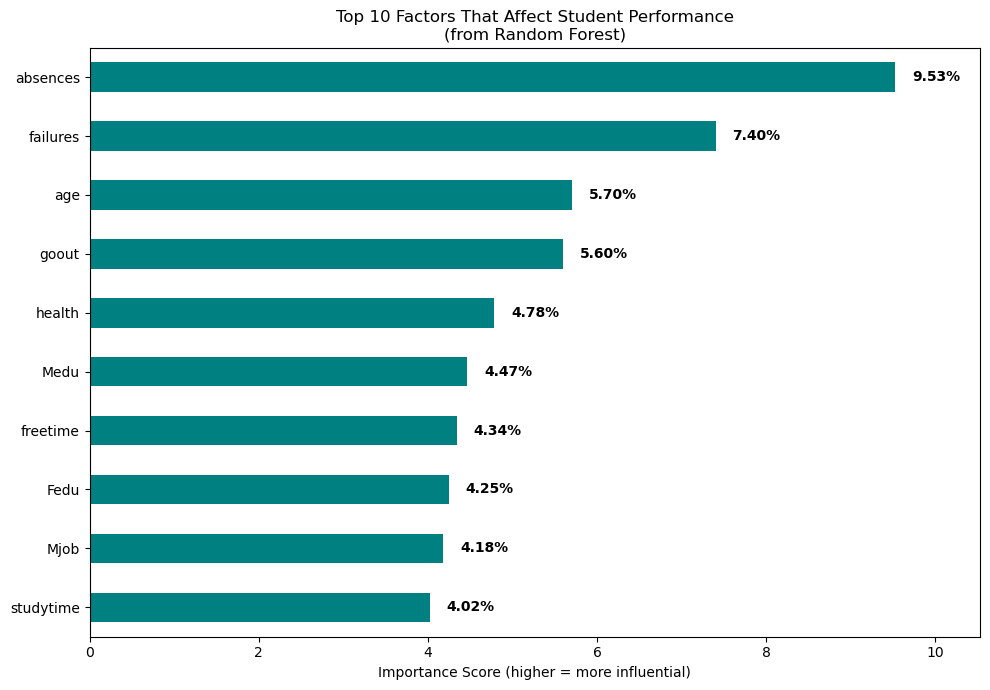


Top 10 most important features:
absences     9.53%
failures     7.40%
age          5.70%
goout        5.60%
health       4.78%
Medu         4.47%
freetime     4.34%
Fedu         4.25%
Mjob         4.18%
studytime    4.02%
dtype: object


In [75]:
# Feature Importance Chart
# Random Forest can rank which features it used the most
# Higher bar = that feature had more influence on the prediction
# This directly can answer our question : "Which factors affect student performance?"

feature_importance = pd.Series(
    rf_model.feature_importances_ * 100,      # importance score for each feature
    index=X.columns                           # label each score with its column name
).sort_values(ascending=True).tail(10)        # top 10, sorted for horizontal bar chart

plt.figure(figsize=(10, 7))
bars = feature_importance.plot(kind='barh', color='teal')

# Add the % labels inside or next to the bars
for i, v in enumerate(feature_importance):
    plt.text(v + 0.2 , i, f'{v:.2f}%', va='center', fontweight='bold')

plt.title('Top 10 Factors That Affect Student Performance\n(from Random Forest)', fontsize=12)
plt.xlabel('Importance Score (higher = more influential)')
plt.xlim(0, max(feature_importance) + 1) 
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 10 most important features:")
print(feature_importance.sort_values(ascending=False).map('{:.2f}%'.format))

In [76]:
# Full Classification Report for Each Model
# This gives 3 extra metrics beyond accuracy:

# Precision = when model says "Pass", how often is it correct?
# e.g. 0.76 = 76% of "Pass" predictions were right

# Recall = Out of all actual Pass students, how many did model catch?
# e.g. 0.92 = model caught 92% of real passes

# F1-Score  = balance between Precision and Recall (a combined number)
# useful when classes are imbalanced (we have more Pass than Fail)

for name, preds in all_models:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, target_names=['Fail', 'Pass']))


  Decision Tree
              precision    recall  f1-score   support

        Fail       0.80      0.30      0.43        27
        Pass       0.72      0.96      0.83        52

    accuracy                           0.73        79
   macro avg       0.76      0.63      0.63        79
weighted avg       0.75      0.73      0.69        79


  Random Forest
              precision    recall  f1-score   support

        Fail       0.73      0.30      0.42        27
        Pass       0.72      0.94      0.82        52

    accuracy                           0.72        79
   macro avg       0.72      0.62      0.62        79
weighted avg       0.72      0.72      0.68        79


  Logistic Regression
              precision    recall  f1-score   support

        Fail       0.75      0.44      0.56        27
        Pass       0.76      0.92      0.83        52

    accuracy                           0.76        79
   macro avg       0.76      0.68      0.70        79
weighted avg     